# Milestone 1: Exploratory Data Analysis
DA 401 – Minor in Business Analytics  
Project: Credit Risk Assessment and Loan Default Prediction  
Dataset: Lending Club Loan Data  


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
PROJECT_PATH = "/content/drive/MyDrive/iitmd_ba_2501164_FA-02"


In [ ]:
df_raw = pd.read_csv(
    f"{PROJECT_PATH}/accepted_2007_to_2018Q4.csv",
    low_memory=False
)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = df_raw.copy()



## Dataset Overview

The Lending Club accepted loan dataset contains historical information on approved loan applications, including borrower demographics, credit characteristics, loan attributes, and repayment outcomes. The dataset is used to analyze default behavior among borrowers and to identify early indicators of credit risk.

Only loans with final outcomes (`Fully Paid` and `Charged Off`) are retained for analysis to ensure a clear definition of default. This filtered dataset forms the basis for all subsequent exploratory and modeling steps.


In [ ]:
df = df.sample(n=30000, random_state=42)


In [ ]:
df.shape
df['loan_status'].value_counts()


,count
loan_status,
Fully Paid,14286
Current,11625
Charged Off,3578
Late (31-120 days),308
In Grace Period,110
Late (16-30 days),67
Does not meet the credit policy. Status:Fully Paid,16
Does not meet the credit policy. Status:Charged Off,10


In [ ]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

df['default'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})


## Target Variable Definition

Loan default is defined using the `loan_status` variable. Loans marked as **Fully Paid** are considered non-default cases, while loans marked as **Charged Off** are treated as defaults.

A binary target variable named `default` is created:
- `0` → Fully Paid (Non-default)
- `1` → Charged Off (Default)

This binary representation enables quantitative analysis of default patterns and supports predictive modeling in later stages of the project.


In [ ]:
df['default'].value_counts(normalize=True) * 100


,proportion
default,
0,79.970891
1,20.029109


In [ ]:
leak_cols = [
    'id', 'member_id', 'total_pymnt', 'total_pymnt_inv',
    'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt'
]

df = df.drop(columns=[c for c in leak_cols if c in df.columns])


## Removal of Data Leakage Variables

Certain variables in the dataset are generated after loan approval or during the repayment period. Including such variables would introduce data leakage and lead to unrealistic model performance.

To maintain the integrity of the analysis, all post-approval and repayment-related variables were removed. Only information available at the time of loan application is retained, ensuring that insights and models reflect real-world lending scenarios.


In [ ]:
# Drop columns with >30% missing
df = df.loc[:, df.isnull().mean() < 0.3]

# Fill numerical with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


## Missing Value Treatment

The dataset contains missing values across several variables. Missing data was handled using a rule-based approach aligned with the project guidelines:

- Columns with more than 30% missing values were removed.
- Numerical variables with limited missingness were imputed using the median.
- Categorical variables were imputed using the mode.

This approach preserves data integrity while minimizing potential bias introduced by missing values.


In [ ]:
df = df[df['annual_inc'] <= 100000]
df = df[df['dti'] <= 60]
df = df[(df['loan_amnt'] >= 1000) & (df['loan_amnt'] <= 40000)]


## Outlier Treatment

Extreme values were identified and removed based on business rules provided in the project brief. These thresholds reflect realistic borrower behavior and lending constraints.

Outlier treatment was applied to variables such as annual income, debt-to-income ratio, and loan amount to reduce skewness and improve the reliability of exploratory analysis. The resulting dataset represents a cleaner and more realistic borrower population.


In [ ]:
df.shape


(14577, 87)

In [ ]:
key_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low']

df[key_cols].describe()


,loan_amnt,int_rate,annual_inc,dti,fico_range_low
count,14577.000000,14577.000000,14577.000000,14577.000000,14577.000000
mean,12760.369075,13.450844,58475.928362,18.778163,694.417919
std,7636.200937,4.782991,20917.155472,8.598240,31.046551
min,1000.000000,5.310000,0.000000,0.000000,660.000000
25%,7000.000000,9.990000,42000.000000,12.410000,670.000000
50%,11100.000000,12.990000,57100.000000,18.330000,685.000000
75%,17150.000000,16.200000,75000.000000,24.800000,710.000000
max,40000.000000,30.990000,100000.000000,59.640000,845.000000


In [ ]:
total_loans = df.shape[0]
avg_loan = df['loan_amnt'].mean()
avg_rate = df['int_rate'].mean()
default_rate = df['default'].mean() * 100

total_loans, avg_loan, avg_rate, default_rate


(14577,
 np.float64(12760.369074569528),
 np.float64(13.450843795019551),
 np.float64(20.930232558139537))

## Exploratory Data Analysis Approach

Exploratory Data Analysis (EDA) was conducted to understand default patterns across key borrower and loan segments. The analysis focuses on identifying relationships between default behavior and factors such as income, credit quality, loan grade, employment characteristics, and loan purpose.

These insights provide the foundation for hypothesis testing and predictive modeling in subsequent milestones.


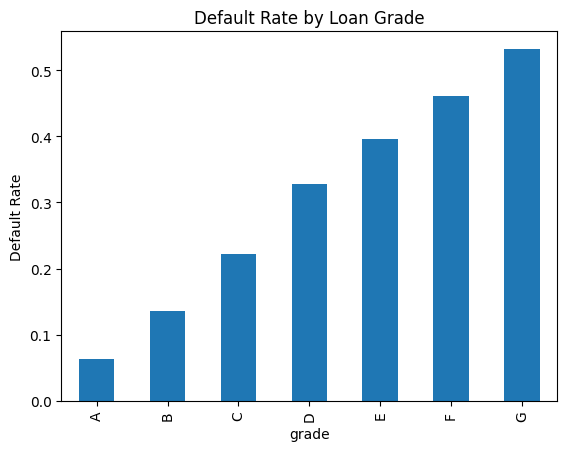

In [ ]:
df.groupby('grade')['default'].mean().sort_index().plot(kind='bar')
plt.ylabel("Default Rate")
plt.title("Default Rate by Loan Grade")
plt.show()


/tmp/ipython-input-682681155.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('income_group')['default'].mean().plot(kind='bar')


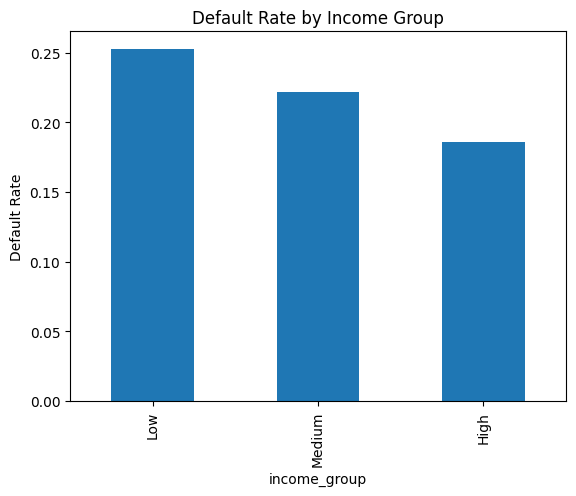

In [ ]:
df['income_group'] = pd.cut(
    df['annual_inc'],
    bins=[0, 30000, 60000, 100000],
    labels=['Low', 'Medium', 'High']
)

df.groupby('income_group')['default'].mean().plot(kind='bar')
plt.ylabel("Default Rate")
plt.title("Default Rate by Income Group")
plt.show()


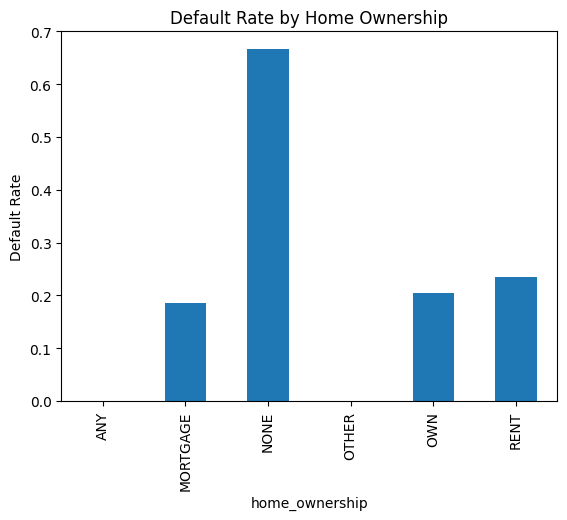

In [ ]:
df.groupby('home_ownership')['default'].mean().plot(kind='bar')
plt.ylabel("Default Rate")
plt.title("Default Rate by Home Ownership")
plt.show()


In [ ]:
purpose_default = df.groupby('purpose')['default'].mean().sort_values(ascending=False)

purpose_default.head(5)


,default
purpose,
small_business,0.292208
medical,0.235955
other,0.232611
debt_consolidation,0.219974
moving,0.216495


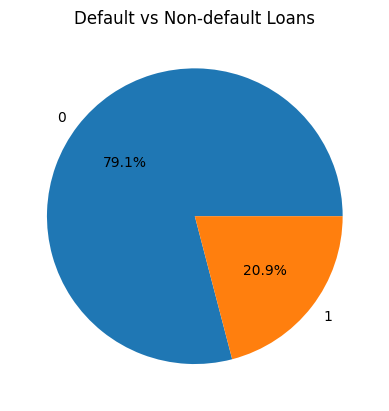

In [ ]:
df['default'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Default vs Non-default Loans")
plt.ylabel("")
plt.show()


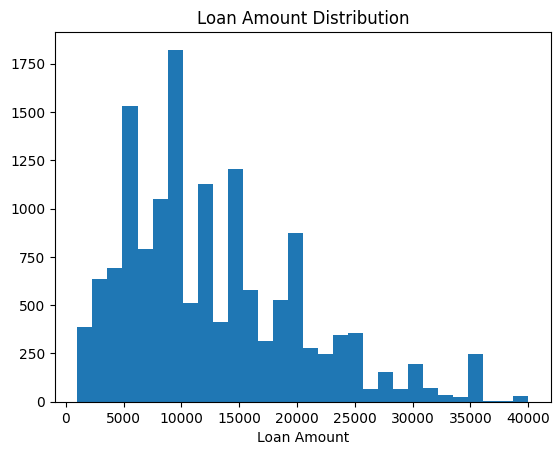

In [ ]:
plt.hist(df['loan_amnt'], bins=30)
plt.xlabel("Loan Amount")
plt.title("Loan Amount Distribution")
plt.show()


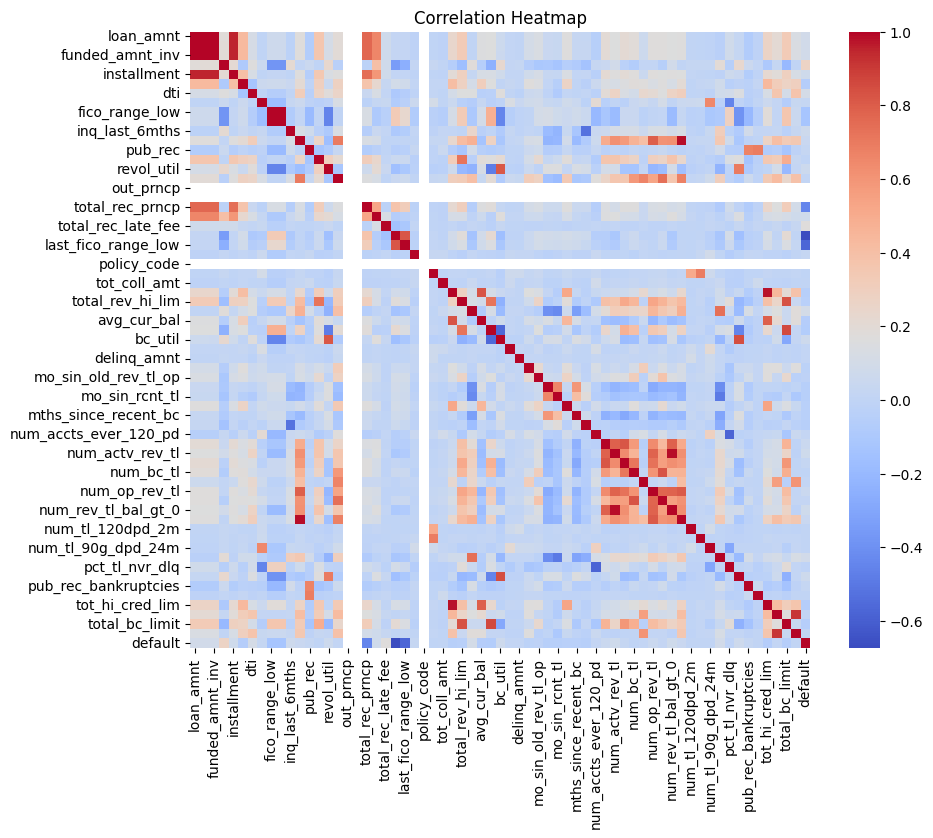

In [ ]:
num_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


## Key Insights from Milestone 1 (EDA)

1. Loan grade is the strongest indicator of default risk, with default rates increasing monotonically from Grade A to Grade G.
2. Borrowers in the low-income segment show significantly higher default rates compared to medium and high-income groups.
3. Renters exhibit higher default risk than homeowners and borrowers with mortgages.
4. Certain loan purposes (e.g., small business, other) are associated with elevated default rates.
5. Higher DTI and lower FICO scores are positively correlated with loan default.


In [ ]:
df.to_csv(
    "/content/drive/MyDrive/IIT Project/cleaned_lending_club.csv",
    index=False
)


In [ ]:
!ls "/content/drive/MyDrive/IIT Project"


 accepted_2007_to_2018Q4.csv  'Milestone 1'  'Milestone 4'
 cleaned_lending_club.csv     'Milestone 2'
 credit_risk_dataset.csv      'Milestone 3'
